In [2]:
cd/Users/sobhan.ahmadian.moghadam/PycharmProjects/IDRPrediction

/Users/sobhan.ahmadian.moghadam/PycharmProjects/IDRPrediction


# Disprot Dataset

In [3]:
from src.data.data import get_disprot_data, SEQUENCES, DISORDER_REGIONS, ID

In [4]:
data = get_disprot_data()

In [5]:
def print_data(j):
    print('id :', data[ID][j])
    print('length :', len(data[SEQUENCES][j]))
    print(' '.join(data[SEQUENCES][j]))
    s = ''
    for i in range(len(data[DISORDER_REGIONS][j])):
        s += str(data[DISORDER_REGIONS][j][i])
    print(' '.join(s))

In [6]:
print_data(1)

id : DP00004
length : 170
M K T Q R D G H S L G R W S L V L L L L G L V M P L A I I A Q V L S Y K E A V L R A I D G I N Q R S S D A N L Y R L L D L D P R P T M D G D P D T P K P V S F T V K E T V C P R T T Q Q S P E D C D F K K D G L V K R C M G T V T L N Q A R G S F D I S C D K D N K R F A L L G D F F R K S K E K I G K E F K R I V Q R I K D F L R N L V P R T E S
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1


# Length of Sequences

In [7]:
lens = [len(s) for s in data[SEQUENCES]]
n = len(data[SEQUENCES])

2365


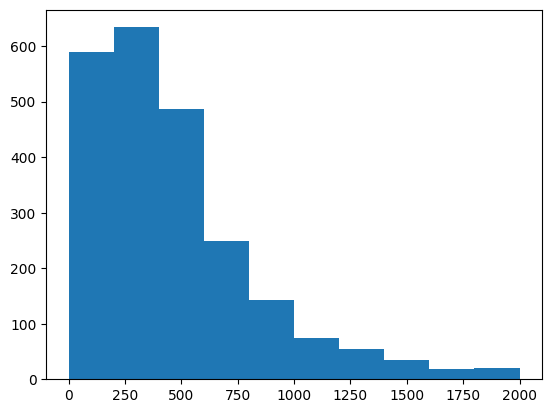

In [8]:
import matplotlib.pyplot as plt

print(len(data[SEQUENCES]))
plt.hist(lens, range=(0, 2000));

2365


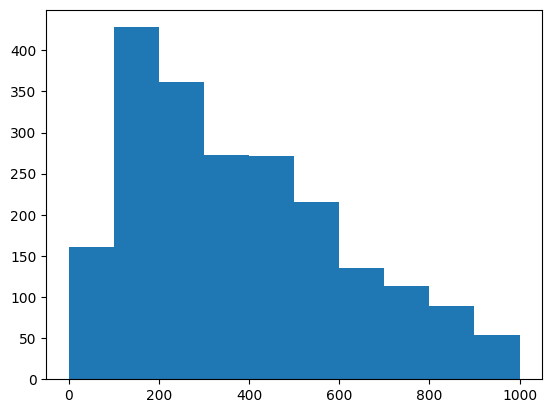

In [9]:
import matplotlib.pyplot as plt

print(len(data['sequences']))
plt.hist(lens, range=(0, 1000));

In [10]:
print('minimum length : ', min(lens))
print('maximum length : ', max(lens))

minimum length :  19
maximum length :  34350


In [11]:
max_length = 500
i = sum([1 for l in lens if l <= max_length])
print(f'number and percent of seq with length lower than or equal to {max_length} : ', i, '  ',
      "{:.1f}".format(i / n * 100) + '%')

i = sum([1 for l in lens if l > max_length])
print(f'number and percent of seq with length larger than {max_length} :            ', i, '   ',
      "{:.1f}".format(i / n * 100) + '%')

number and percent of seq with length lower than or equal to 500 :  1497    63.3%
number and percent of seq with length larger than 500 :             868     36.7%


# Disorder Regions

In [12]:
labels = data[DISORDER_REGIONS]
r_sequences = []
r_numbers = []

for label in labels:
  r_seq = []
  r_num = []
  i = 0
  c = True

  while c:
    r_seq.append(label[i])
    num = 1
    b = label[i]

    if i + num >= len(label):
      r_num.append(num)
      break

    while b == label[i + num]:
      num = num + 1

      if i + num >= len(label):
        c = False
        break
    i = i + num
    r_num.append(num)

  r_sequences.append(r_seq)
  r_numbers.append(r_num)

del labels

## Length of Disorder Regions

In [13]:
dr_lens = [r_numbers[i][j] for i, x in enumerate(r_sequences) for j, y in enumerate(x) if y == 1]


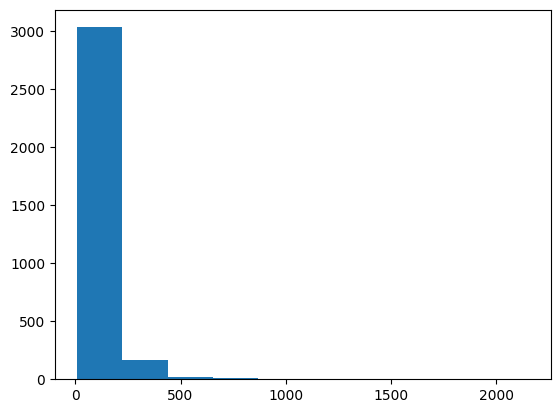

In [14]:
plt.hist(dr_lens, range=(min(dr_lens), max(dr_lens)));

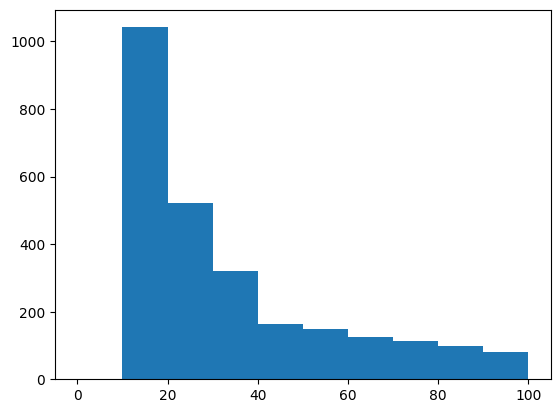

In [15]:
plt.hist(dr_lens, range=(0, 100));

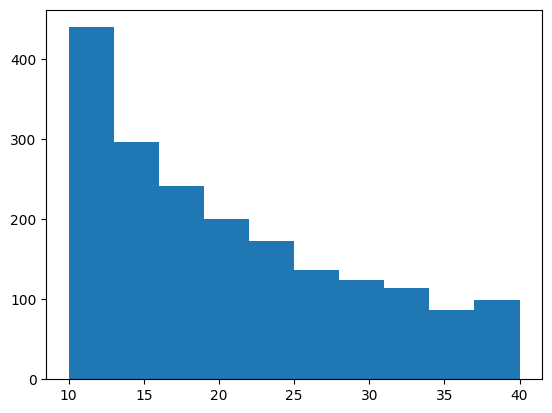

In [16]:
plt.hist(dr_lens, range=(10, 40));

In [17]:
import numpy as np

print('mean  : ', "{:.2f}".format(np.mean(dr_lens)))
print('var   : ', "{:.2f}".format(np.var(dr_lens)))
print('range : ', max(dr_lens) - min(dr_lens))
print('min   : ', min(dr_lens))
print('max   : ', max(dr_lens))

mean  :  69.99
var   :  12709.13
range :  2142
min   :  10
max   :  2152


In [18]:
selected = [r for r in dr_lens if r < 100]

print('mean  : ', "{:.2f}".format(np.mean(selected)))
print('var   : ', "{:.2f}".format(np.var(selected)))
print('range : ', max(selected) - min(selected))

del selected

mean  :  32.27
var   :  524.95
range :  89


## Number of Disorder Regions

In [19]:
dr_nums = [sum(num) for num in r_sequences]

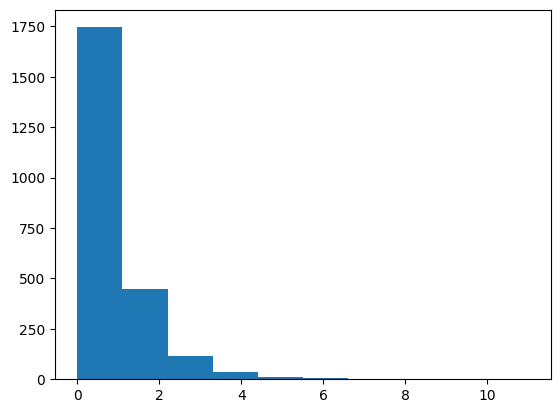

In [20]:
plt.hist(dr_nums, range=[min(dr_nums), max(dr_nums)]);

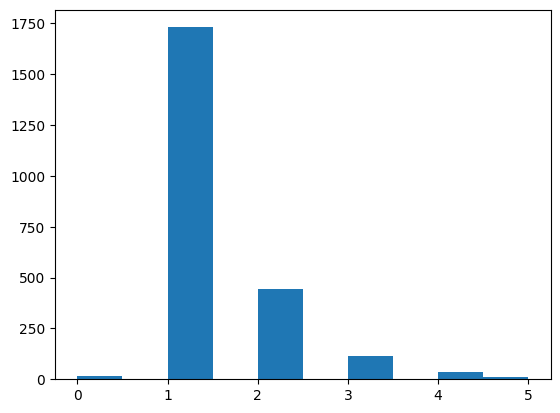

In [21]:
plt.hist(dr_nums, range=[0, 5]);

## Amino Acids

In [22]:
amino_acid_data = {} # dictionary for saving amino acid total information

amino_acids = []
amino_acid_labels = []

for k in range(n):
  sequence = data[SEQUENCES][k]
  labels = data[DISORDER_REGIONS][k]

  amino_acids += [a for a in sequence]
  amino_acid_labels += labels

In [23]:
import json

amino_acid_disorder_numbers = {}
amino_acid_numbers = {}

for i in range(len(amino_acid_labels)):
  if amino_acids[i] not in amino_acid_disorder_numbers:
    amino_acid_disorder_numbers[amino_acids[i]] = 1
  else:
    amino_acid_disorder_numbers[amino_acids[i]] = amino_acid_disorder_numbers[amino_acids[i]] + amino_acid_labels[i]

  if amino_acids[i] not in amino_acid_numbers:
    amino_acid_numbers[amino_acids[i]] = 1
  else:
    amino_acid_numbers[amino_acids[i]] = amino_acid_numbers[amino_acids[i]] + 1

amino_acid_disorder_percent = {}

for ac in amino_acid_disorder_numbers:
  amino_acid_disorder_percent[ac] = round(amino_acid_disorder_numbers[ac] / amino_acid_numbers[ac], 2)

del amino_acid_disorder_numbers
del amino_acid_numbers

In [24]:
print(json.dumps(amino_acid_disorder_percent, indent = 4))

{
    "M": 0.15,
    "A": 0.19,
    "S": 0.21,
    "R": 0.18,
    "E": 0.22,
    "Q": 0.2,
    "T": 0.18,
    "P": 0.22,
    "G": 0.2,
    "D": 0.2,
    "V": 0.14,
    "K": 0.2,
    "I": 0.12,
    "L": 0.13,
    "F": 0.13,
    "N": 0.18,
    "H": 0.16,
    "W": 0.1,
    "Y": 0.13,
    "C": 0.09,
    "X": 0.2,
    "U": 1.0,
    "Z": 1.0
}


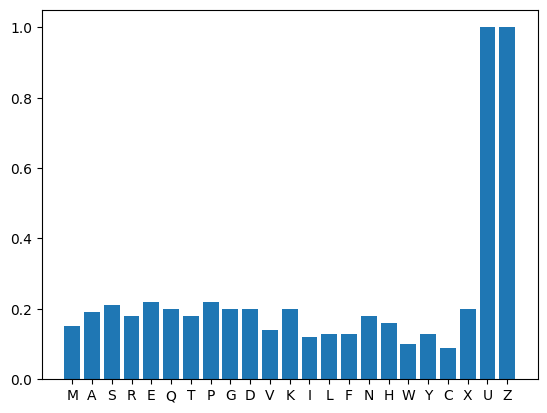

In [25]:
plt.bar(list(amino_acid_disorder_percent.keys()), list(amino_acid_disorder_percent.values()));

# Data Balance

In [27]:
print('disorder percent : ', sum([sum(s) for s in data[DISORDER_REGIONS]]) / sum(lens))

disorder percent :  0.17720031288754412
